The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

### BERT Observation
BERT embeddings were computed on a reduced subset (300 training and 300 test samples) due to computational constraints on CPU. Consequently, the BERT model was trained on significantly less data than the TF-IDF models, and its performance should be interpreted accordingly.

## Initialization

In [1]:
import math
import re

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews.shape, df_reviews.columns

((47331, 17),
 Index(['tconst', 'title_type', 'primary_title', 'original_title', 'start_year',
        'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating',
        'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx'],
       dtype='object'))

In [6]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [7]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [8]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

### Observation: 
No major class imbalance issue and F1 score won’t be distorted

In [9]:
df_reviews['ds_part'].value_counts()

train    23796
test     23535
Name: ds_part, dtype: int64

### Observations: 
Almost perfectly split, there is no need to re-split later with train_test_split()

In [10]:
df_reviews['start_year'].describe()

count    47331.000000
mean      1989.631235
std         19.600364
min       1894.000000
25%       1982.000000
50%       1998.000000
75%       2004.000000
max       2010.000000
Name: start_year, dtype: float64

### Observations: 
Distribution looks realistic

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Good transparency about computational constraints.
Proper warning that BERT results should be interpreted cautiously.

## EDA

Let's check the number of movies and reviews over years.

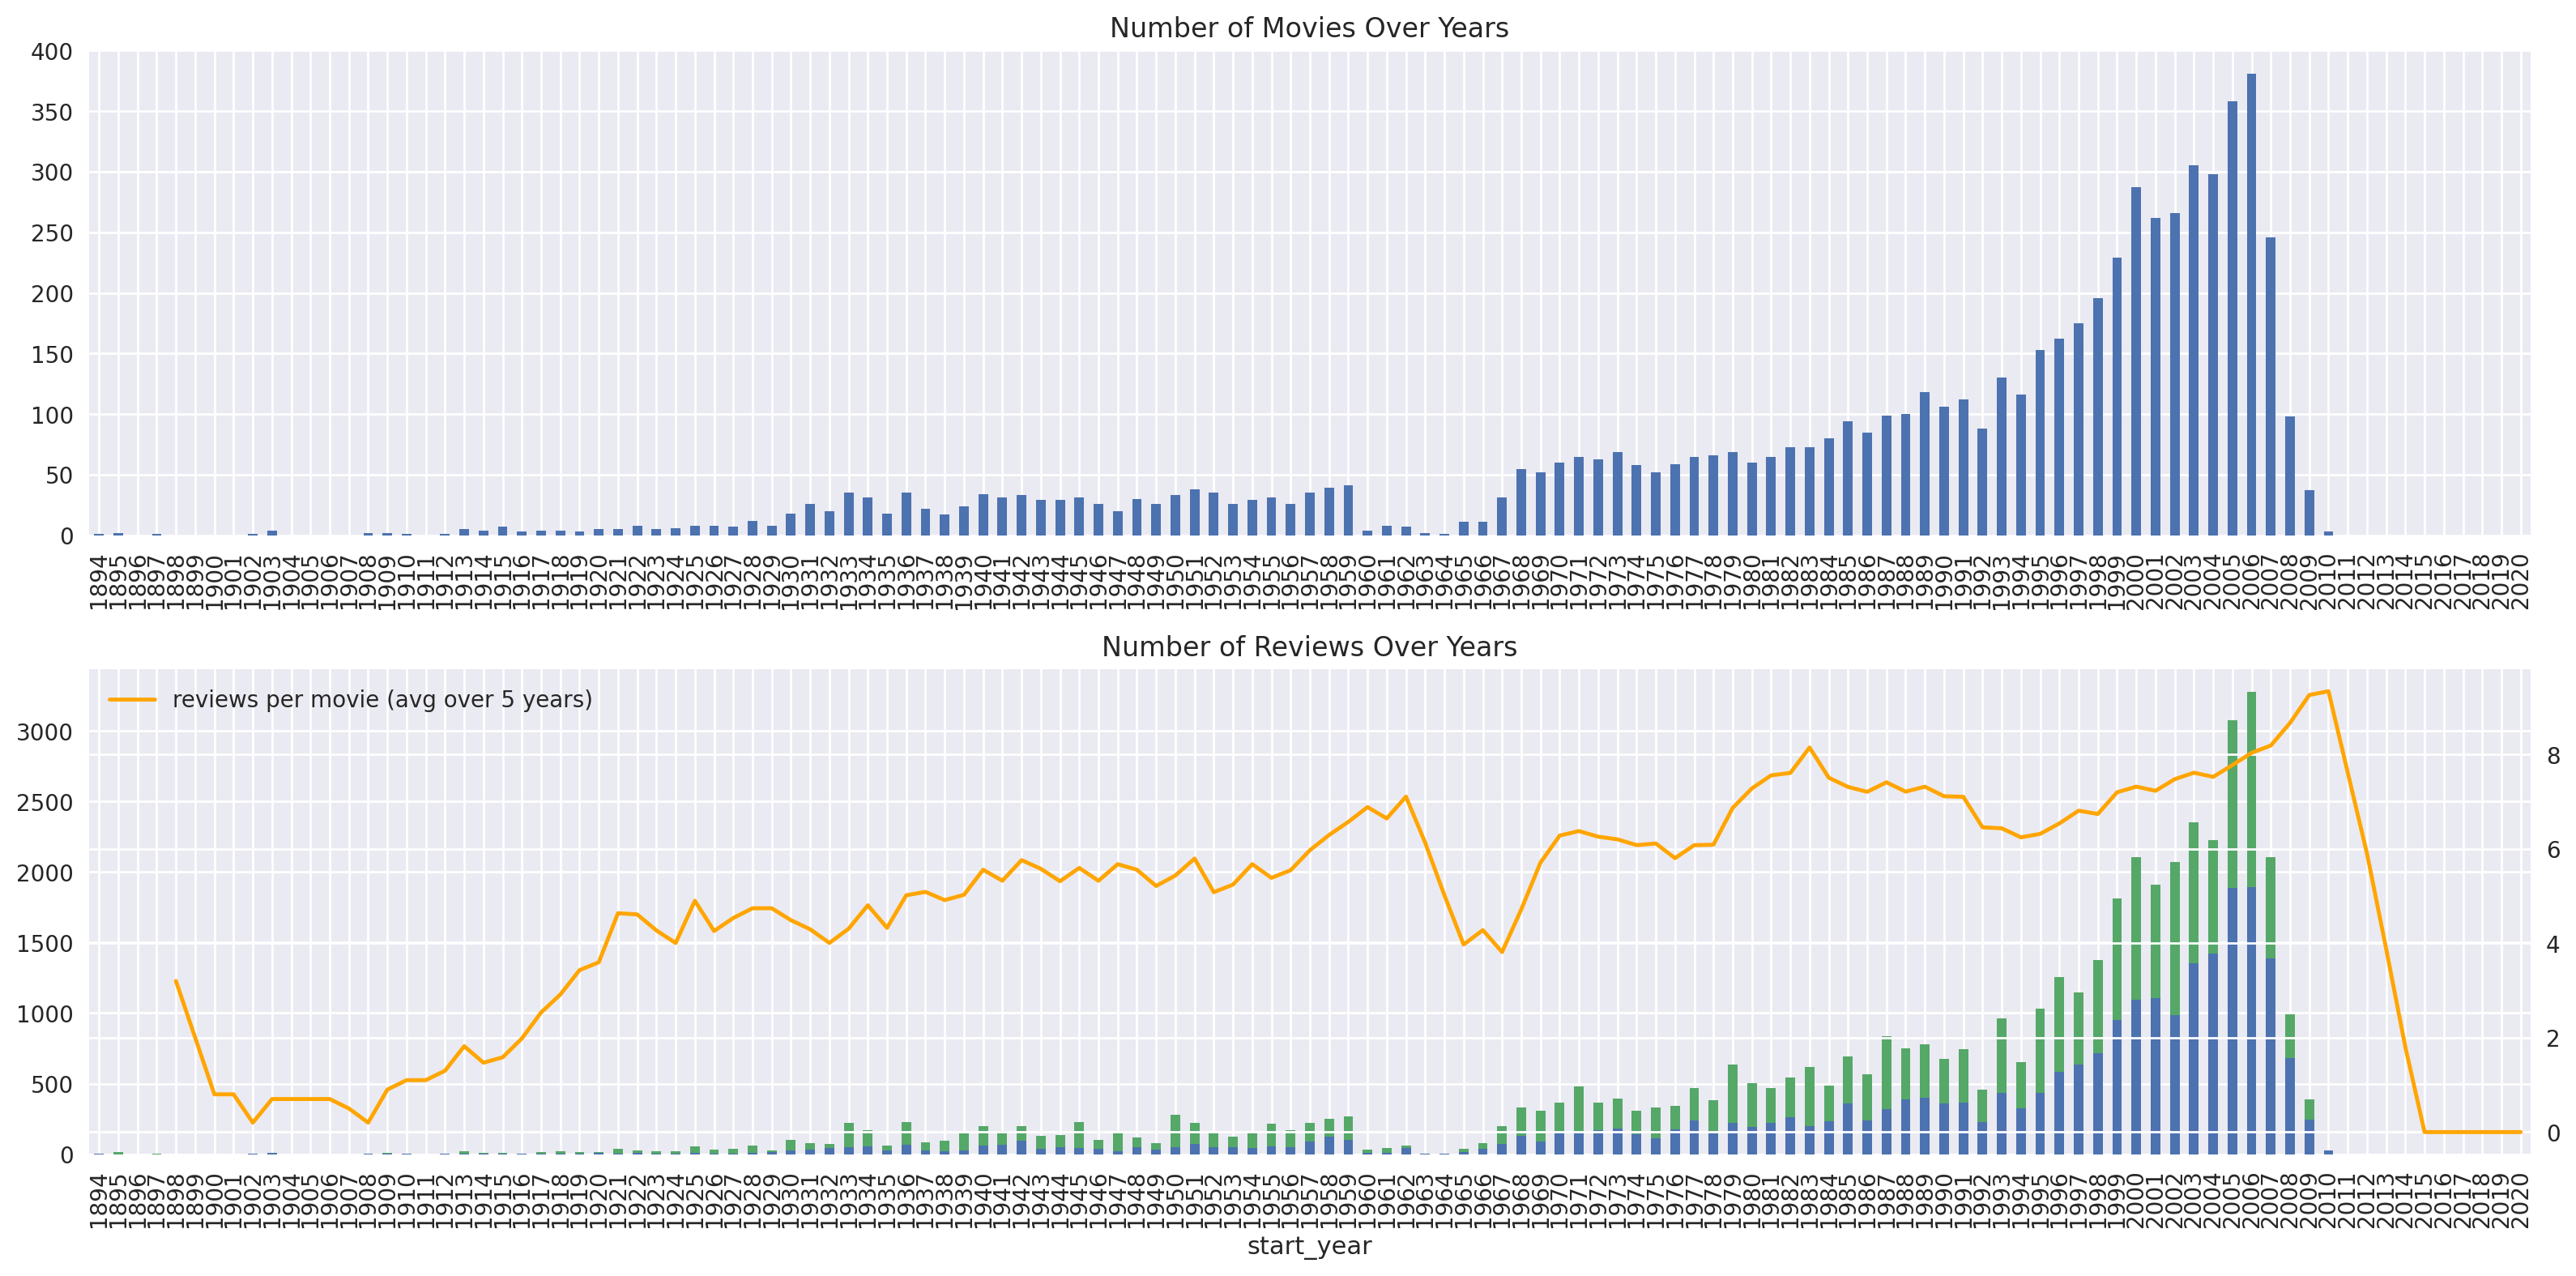

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()



### Observations: 
Number of Movies over the years:
* The dataset is heavily skewed toward modern movies
* Older decades are underrepresented
* The final drop is probably because data stops around 2010

Number of reviews over years:
* Negative and positive reviews grow over time proportionally and confirms balance across years
* Reviews per movie increase over time and modern movies receive more reviews
* Sharp drop at the end could be realted to incomplete recent data

Modern films receive more reviews per movie. However, the distribution of positive and negative reviews remains relatively balanced across years. Therefore, no strong temporal bias is observed that would impact sentiment classification.

In [12]:
df_reviews['review_length'] = df_reviews['review'].str.len()
df_reviews['review_length'].describe()

count    47331.000000
mean      1290.030973
std        974.976807
min         32.000000
25%        691.000000
50%        957.000000
75%       1566.000000
max      13594.000000
Name: review_length, dtype: float64

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

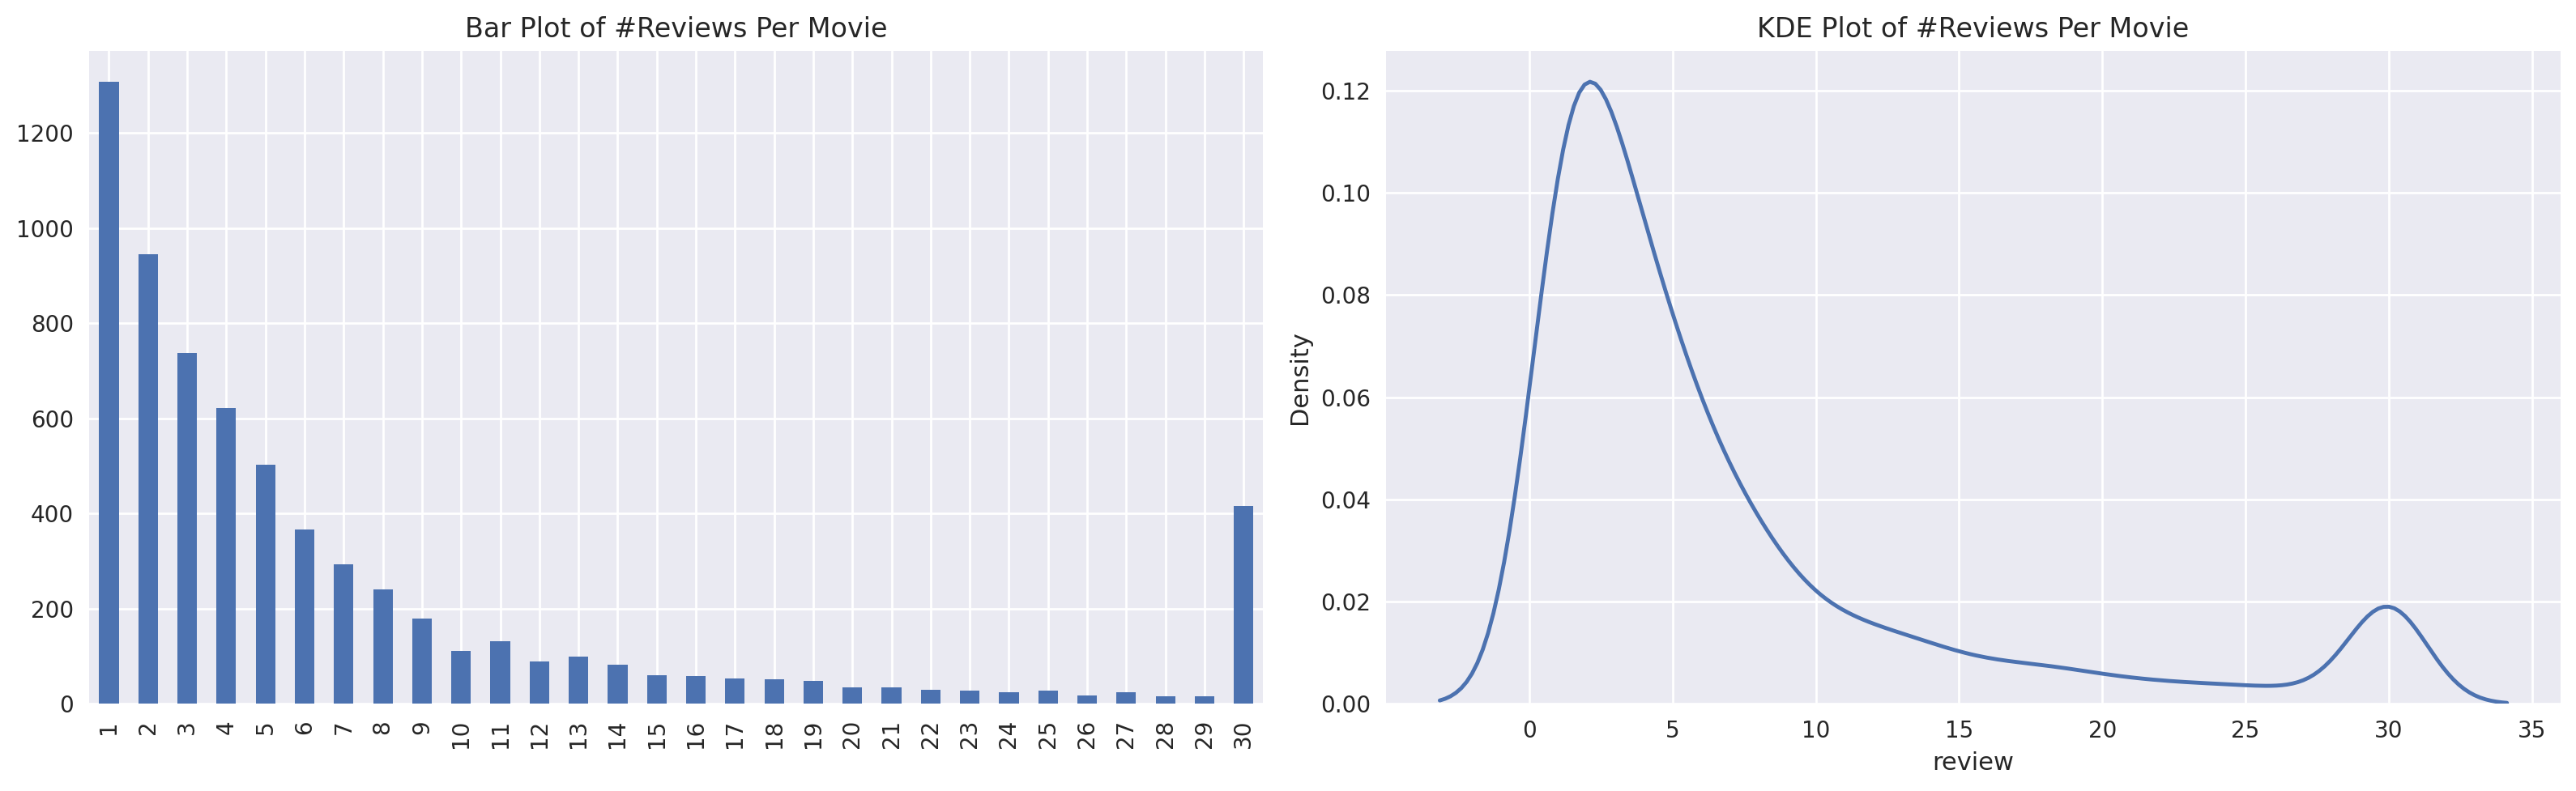

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

### Observation:
The distribution of reviews per movie is heavily right-skewed. Most movies receive only a small number of reviews, while a small subset of movies accumulates many reviews. Since the classification task is performed at the review level, this imbalance does not directly impact model training.

In [14]:
df_reviews['review_length'] = df_reviews['review'].str.len()

df_reviews.groupby('pos')['review_length'].describe()

,count,mean,std,min,25%,50%,75%,max
pos,,,,,,,,
0,23715.0,1273.014421,929.606737,32.0,697.0,959.0,1542.0,8698.0
1,23616.0,1307.118860,1018.238959,65.0,684.0,955.0,1591.0,13594.0


### Observations

The average review length is similar across positive and negative classes, with medians around 950 characters. This suggests that sentiment is not strongly correlated with review length. While positive reviews show slightly higher variance and longer maximum lengths, the overall distributions are comparable.

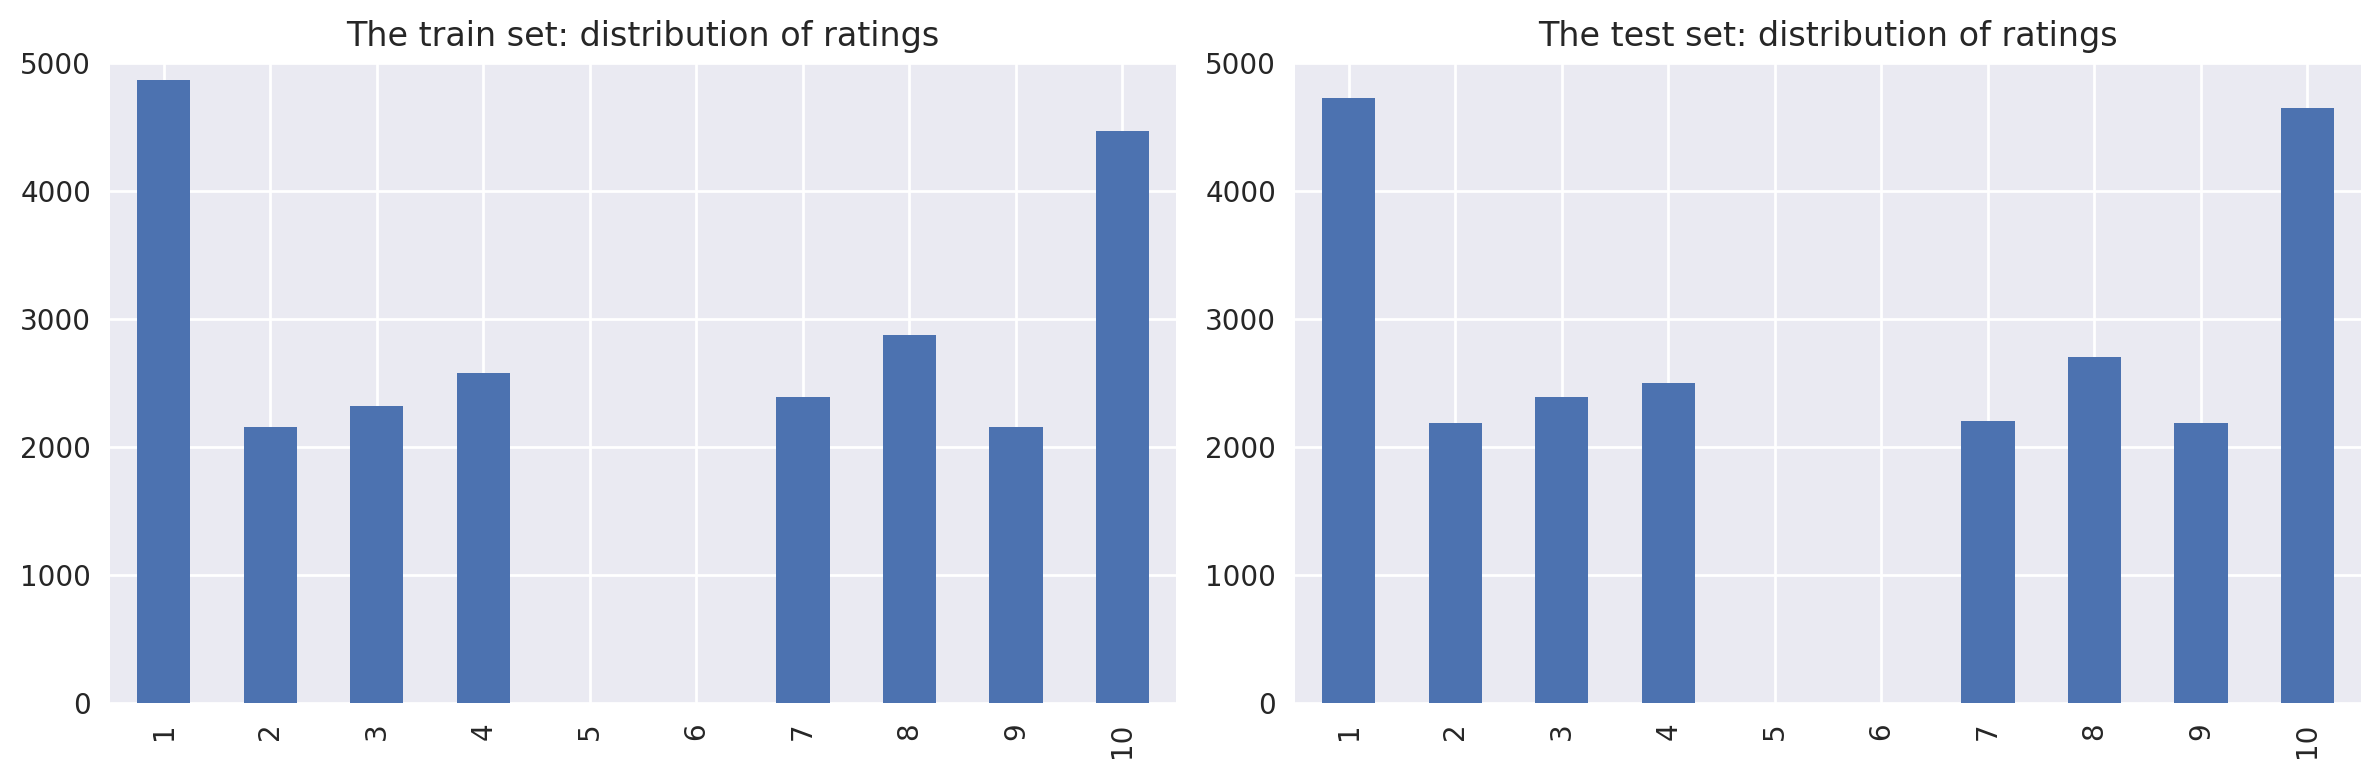

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

### Observations

The rating distributions in the train and test sets are nearly identical, indicating that the dataset split preserves the original rating distribution. The ratings show a clear bimodal pattern, with peaks at extreme values (1 and 10), and relatively few mid-range ratings. This suggests strong sentiment polarity within the dataset.

Distribution of negative and positive reviews over the years for two parts of the dataset

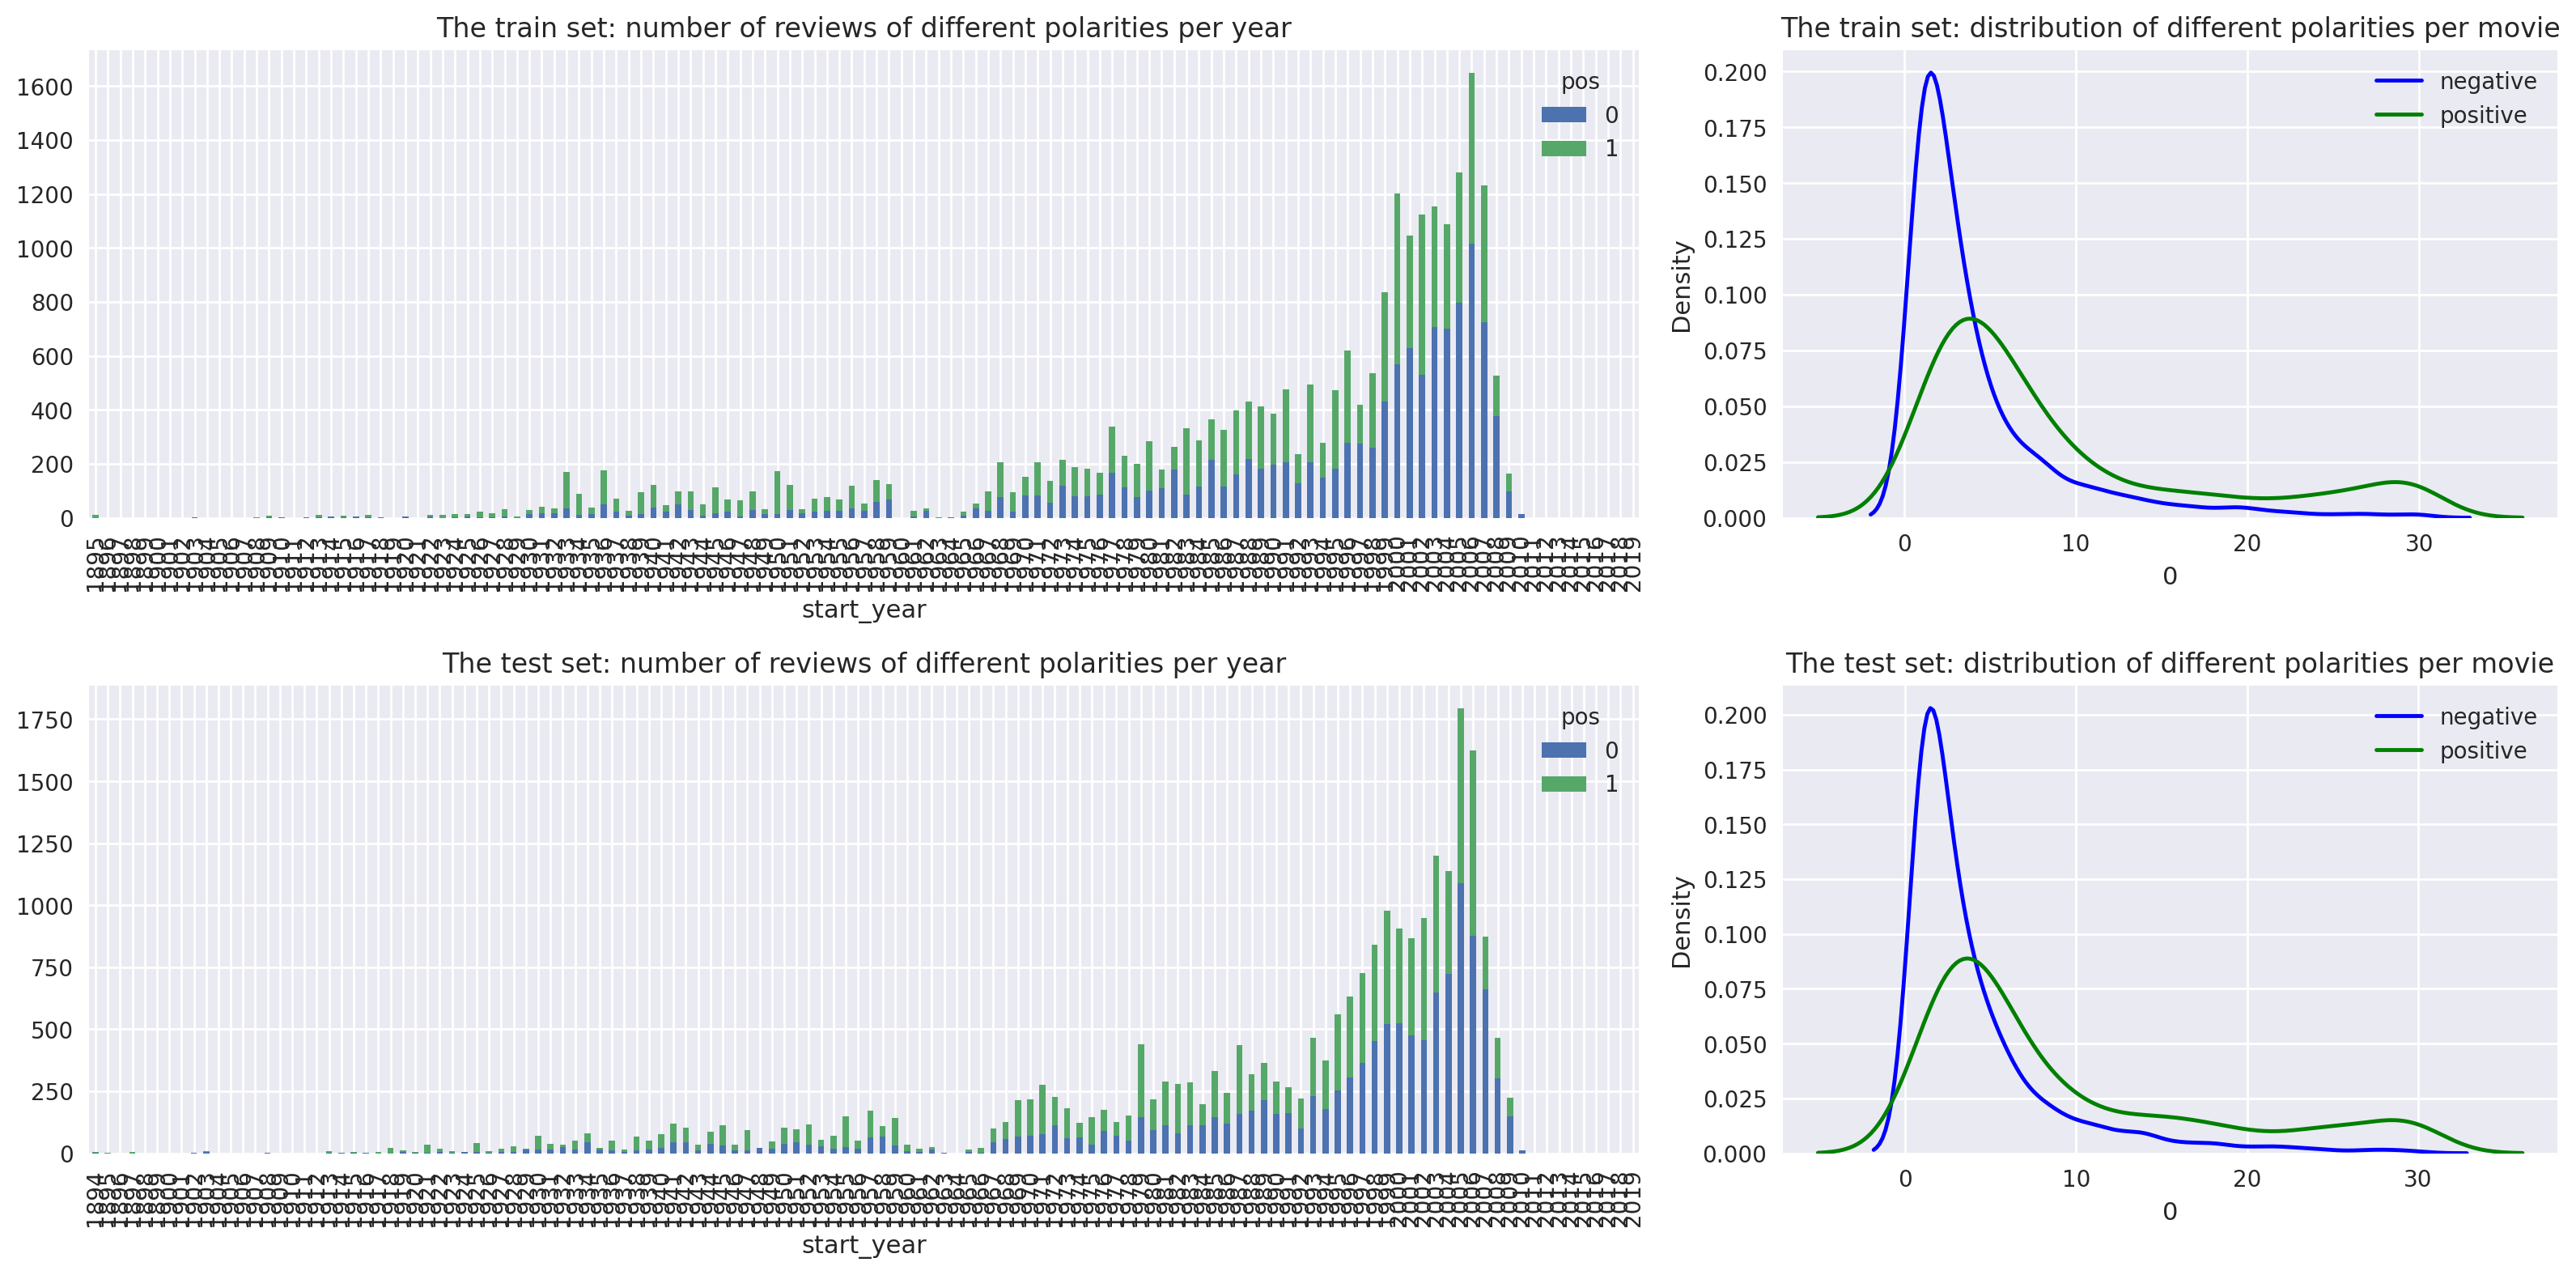

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

### Observations:
The distribution of positive and negative reviews is consistent across both time and dataset splits. Train and test sets exhibit similar polarity patterns over years and per movie. No significant temporal or movie-level sentiment bias is observed, suggesting a fair and reliable dataset for classification modeling.

## Conclusion Class imbalance:
The dataset contains 23,715 negative reviews and 23,616 positive reviews, indicating an almost perfectly balanced class distribution. Therefore, there is no significant class imbalance issue. As a result, special techniques such as class weighting or resampling are not required for model training.

Although the dataset is balanced, F1-score remains an appropriate primary evaluation metric. Accuracy alone can sometimes mask uneven precision–recall trade-offs, even in balanced datasets. F1-score provides a more robust measure by combining precision and recall, ensuring that both false positives and false negatives are properly accounted for. This is particularly important in sentiment classification tasks where misclassifications in either direction may impact downstream applications.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Excellent reporting of exact class counts.

Correct conclusion that classes are nearly perfectly balanced.

Proper justification for not applying resampling techniques.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment v1:</b> </a>

Mention that F1 is still appropriate even in balanced datasets for robustness.

<div class="alert alert-block alert-info">
<b>Ana's comment v1:</b> </a>

updated the conclusion

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [17]:
import sklearn.metrics as metrics

def evaluate_model(
    model,
    train_features, train_target,
    test_features, test_target,
    fixed_threshold=0.5
):
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    # We'll compute threshold curves for train only (no test threshold tuning)
    f1_thresholds = np.arange(0, 1.01, 0.05)

    for dataset_type, features, target in (
        ('train', train_features, train_target),
        ('test', test_features, test_target)
    ):
        eval_stats[dataset_type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[dataset_type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[dataset_type]['APS'] = aps

        color = 'blue' if dataset_type == 'train' else 'green'

        # F1 vs threshold plot
        ax = axs[0]
        if dataset_type == 'train':
            f1_scores = [metrics.f1_score(target, pred_proba >= thr) for thr in f1_thresholds]
            max_idx = int(np.argmax(f1_scores))
            ax.plot(
                f1_thresholds, f1_scores, color=color,
                label=f'{dataset_type}, max={f1_scores[max_idx]:.2f} @ {f1_thresholds[max_idx]:.2f}'
            )
            # mark some thresholds
            for thr in (0.2, 0.4, fixed_threshold, 0.6, 0.8):
                idx = int(np.argmin(np.abs(f1_thresholds - thr)))
                marker_color = 'red' if thr == fixed_threshold else 'orange'
                ax.plot(f1_thresholds[idx], f1_scores[idx], color=marker_color, marker='X', markersize=7)
        else:
            # test: NO threshold optimization
            f1_at_fixed = metrics.f1_score(target, pred_proba >= fixed_threshold)
            ax.scatter([fixed_threshold], [f1_at_fixed], color=color,
                       label=f'{dataset_type}, F1@{fixed_threshold:.2f}={f1_at_fixed:.2f}', marker='X', s=80)

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title('F1 Score')

        #ROC plot
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{dataset_type}, ROC AUC={roc_auc:.2f}')
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title('ROC Curve')

        # PRC plot
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{dataset_type}, AP={aps:.2f}')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title('PRC')

        # Table metrics 
        eval_stats[dataset_type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[dataset_type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats).round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    print(df_eval_stats)

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

Threshold optimization should be applied only on validation, not test (to avoid bias).

Variable name type shadows Python built-in — rename (e.g., dataset_type).

<div class="alert alert-block alert-info">
<b>Ana's comment v1:</b> </a>

Threshold selection is performed only on training/validation data to avoid bias. Test metrics are reported using a fixed threshold (0.5)

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well Done!

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [18]:
df_reviews['review_norm'] = (
    df_reviews['review']
    .str.lower()
    .str.replace(r'\d+', '', regex=True)              # remove digits
    .str.replace(r'[^\w\s]', '', regex=True)          # remove punctuation
    .str.replace(r'\s+', ' ', regex=True)             # remove extra spaces
    .str.strip()
)

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Removes noise (digits, punctuation, extra spaces). Good job.

Lowercasing standardizes input effectively.

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [19]:

df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23796, 19)
(23535, 19)


## Working with models

### Model 0 - Constant

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


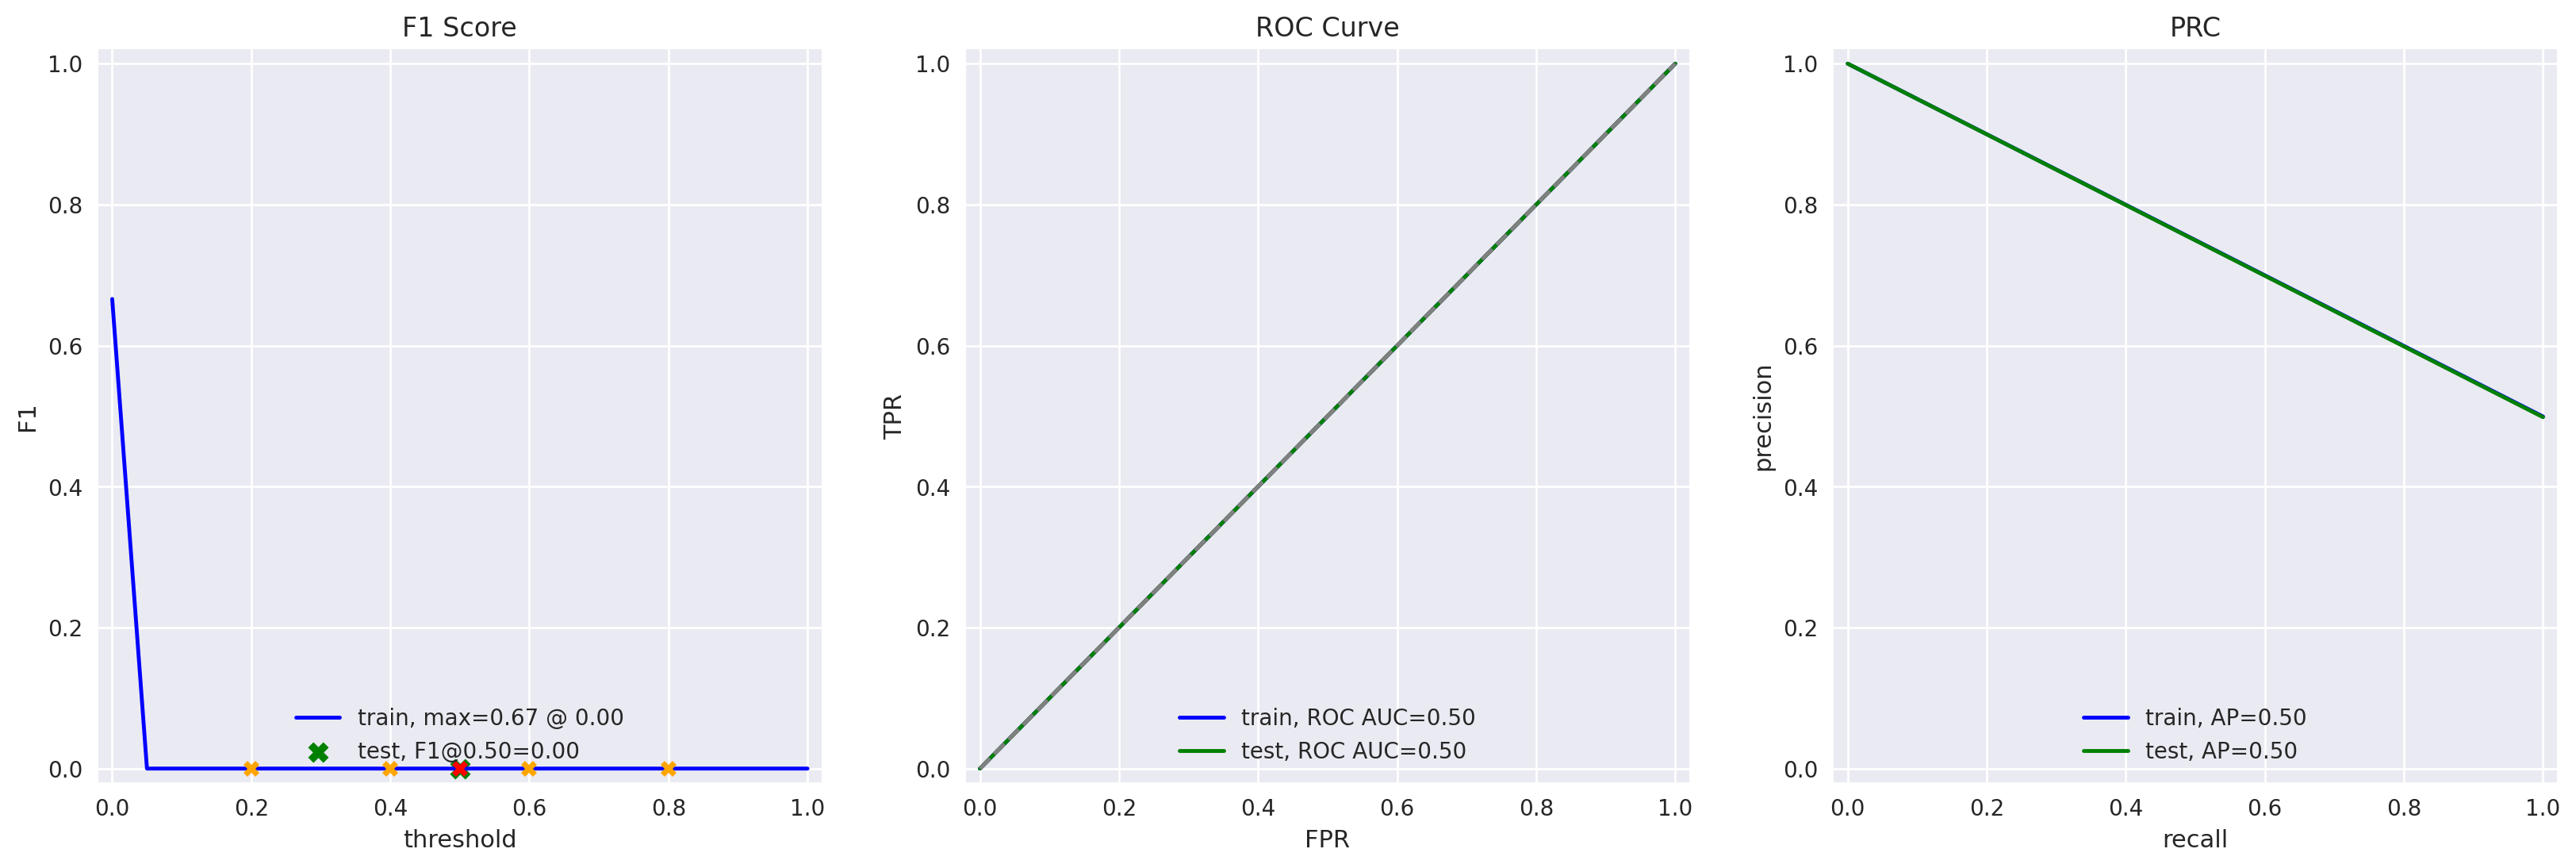

In [20]:
from sklearn.dummy import DummyClassifier

# Features (text column)
train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

# Dummy model
model_0 = DummyClassifier(strategy='most_frequent')

# For dummy, we don't need vectorization
model_0.fit(train_features, train_target)

# Evaluate
evaluate_model(model_0, train_features, train_target, test_features, test_target)

### NEW Observations
The DummyClassifier has ROC AUC = 0.50 and APS = 0.50 on both train and test, which is expected for a non-informative baseline (no ability to separate positive vs negative reviews). Because it predicts only the most frequent class (here, 0 = negative), the F1 score is 0 for the positive class.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

Clarify which class is predicted (negative or positive).

Mention that ROC AUC for dummy should be ~0.5.

<div class="alert alert-block alert-info">
<b>Ana's comment v1:</b> </a>

Corrected comment

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well Done!

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [21]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [22]:
stop_words = stopwords.words('english')

# TF-IDF features
tfidf_1 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

train_features_1 = tfidf_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_1.transform(df_reviews_test['review_norm'])

# Logistic Regression model
model_1 = LogisticRegression(
    max_iter=2000,
    solver='liblinear'  # stable for text + binary
)

model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=2000, solver='liblinear')

          train  test
Accuracy   0.95  0.89
F1         0.95  0.89
APS        0.99  0.95
ROC AUC    0.99  0.95


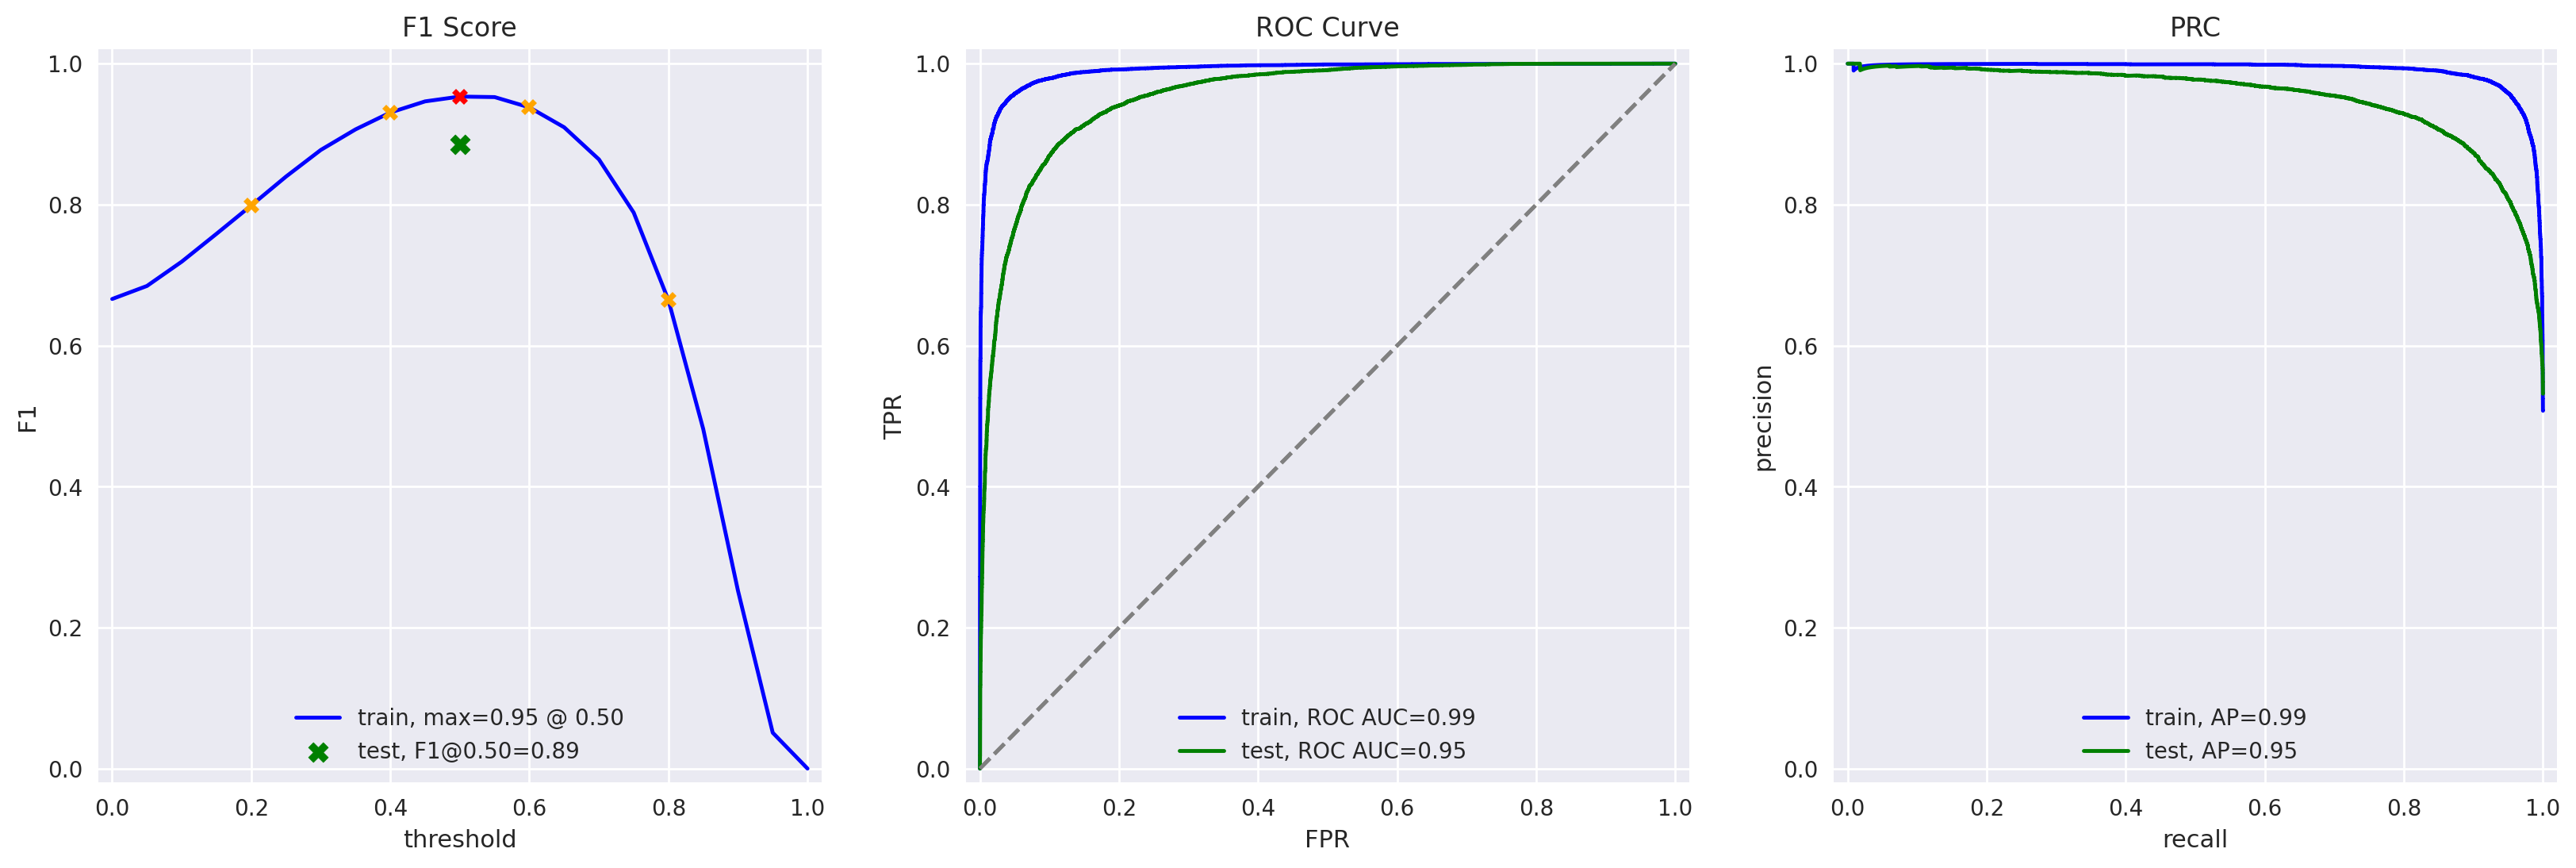

In [23]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Observations

The TF-IDF + Logistic Regression model achieved an F1 score of 0.89 on the test set, exceeding the required threshold of 0.85. The ROC AUC of 0.95 indicates strong discriminative performance. A small gap between training and test scores suggests mild but acceptable overfitting.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Strong model choice for text classification.

Good parameter selection (ngram_range, min_df, max_df).

Appropriate solver (liblinear) for binary classification.

Proper overfitting assessment.

### Model 2: TF-IDF + Multinomial Naive Bayes

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

In [25]:
# TF-IDF
tfidf_2 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

train_features_2 = tfidf_2.fit_transform(df_reviews_train['review_norm'])
test_features_2 = tfidf_2.transform(df_reviews_test['review_norm'])

# Tune alpha with cross-validation
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(train_features_2, train_target)

print("Best alpha:", grid_search.best_params_['alpha'])

model_2 = grid_search.best_estimator_  

Best alpha: 0.5


          train  test
Accuracy   0.97  0.86
F1         0.97  0.85
APS        1.00  0.93
ROC AUC    1.00  0.94


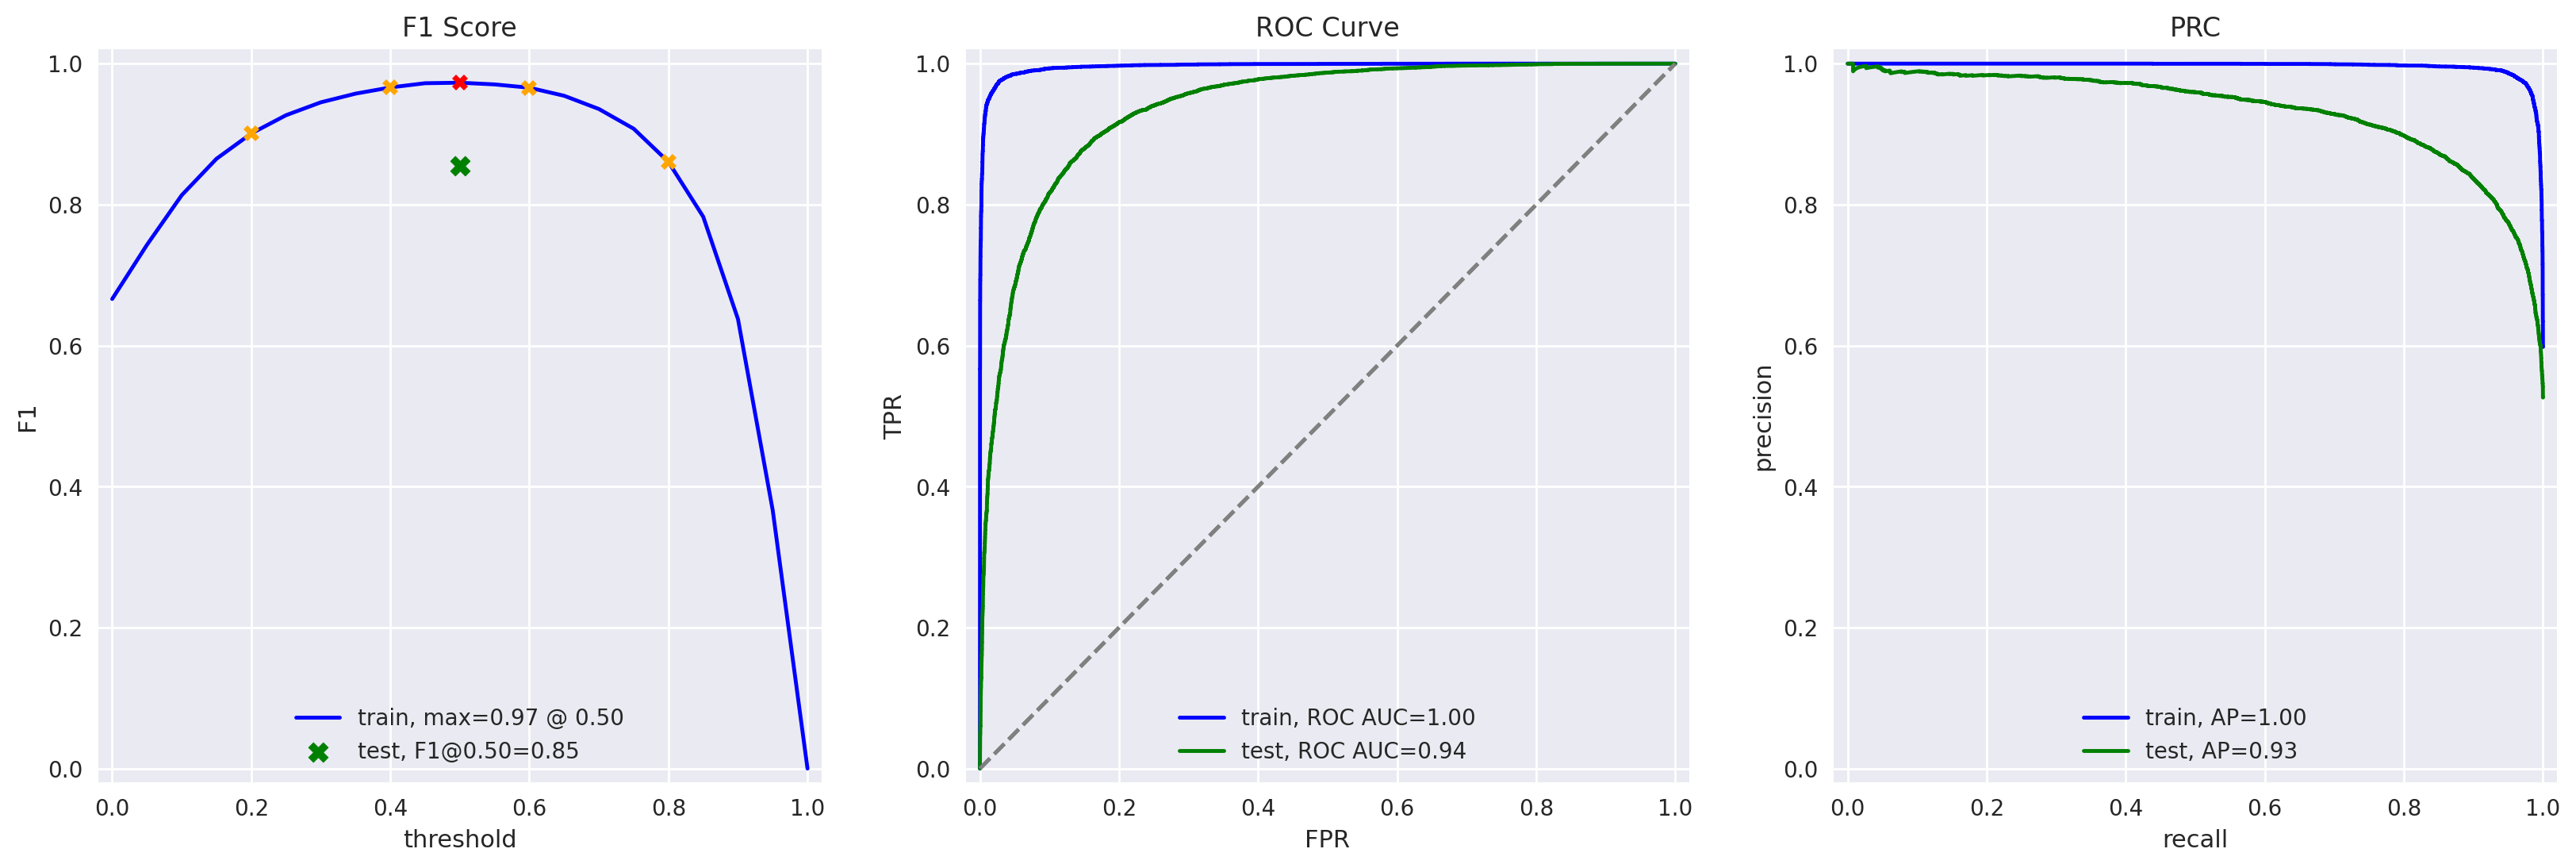

In [26]:
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

### NEW Observations 

With cross-validated alpha, MultinomialNB reached F1 = 0.85 on the test set. The train–test gap (0.97 vs 0.85) suggests overfitting. TF-IDF was used to reduce the impact of very common words and improve generalization; performance remains slightly below Logistic Regression/SGD due to Naive Bayes’ independence assumption.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Appropriate baseline for text classification.

Good comparison against Logistic Regression.

Correct interpretation of independence assumption limitation.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment v1:</b> </a>

Tune alpha using cross-validation instead of fixed 0.5.

Briefly explain why TF-IDF (not raw counts) was used with NB.

Report train vs test gap explicitly to assess overfitting.

<div class="alert alert-block alert-info">
<b>Ana's comment v1:</b> </a>

Alpha tunning was done,and new observations were added 

### Model 3: TF-IDF + SGDClassifier

In [27]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

In [28]:
# TF-IDF
tfidf_3 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

train_features_3 = tfidf_3.fit_transform(df_reviews_train['review_norm'])
test_features_3 = tfidf_3.transform(df_reviews_test['review_norm'])

# SGD (logistic regression trained with SGD)
model_3 = SGDClassifier(
    loss="log",
    alpha=1e-5,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

model_3.fit(train_features_3, train_target)

SGDClassifier(alpha=1e-05, loss='log', random_state=42)

          train  test
Accuracy   0.99  0.89
F1         0.99  0.89
APS        1.00  0.96
ROC AUC    1.00  0.96


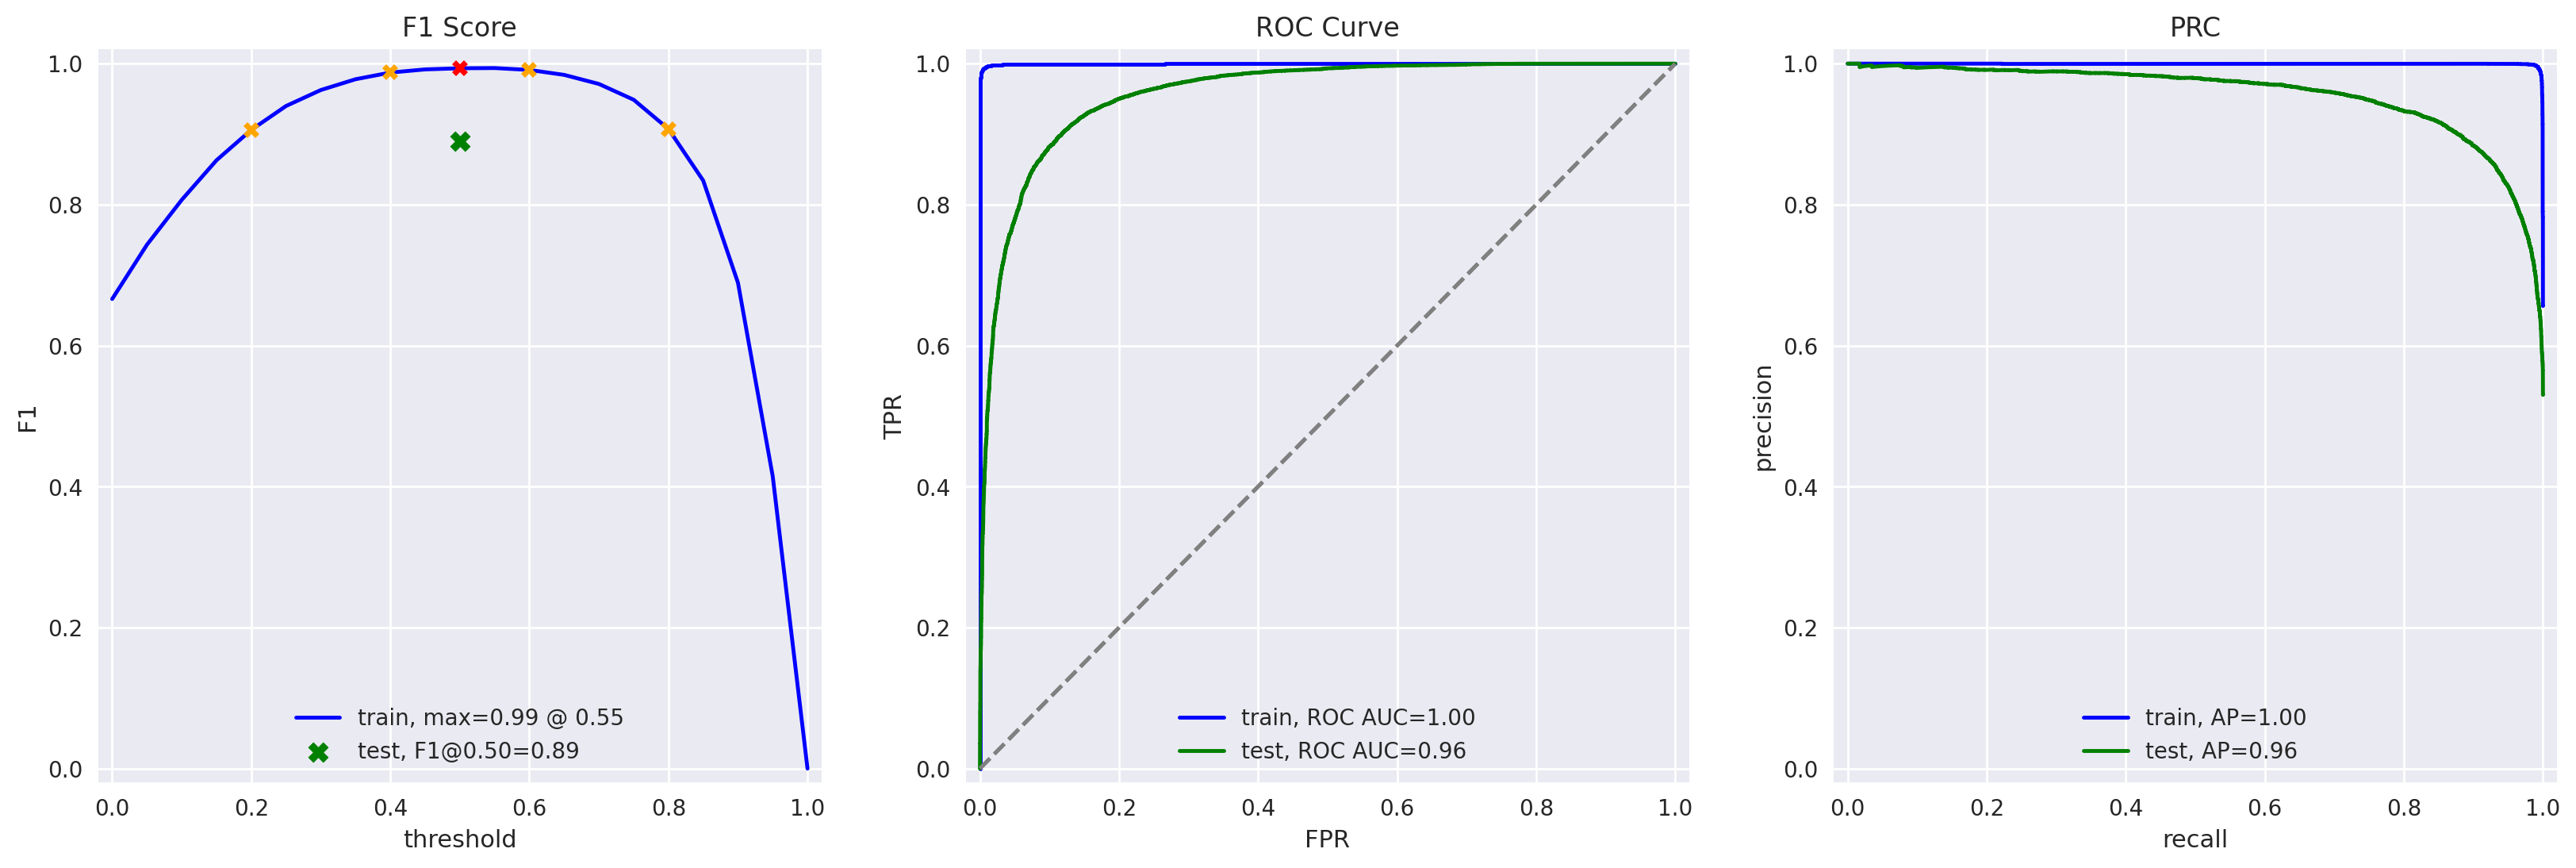

In [29]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Observation:
The SGDClassifier achieved an F1 score of 0.89 on the test set, matching the performance of Logistic Regression. Additionally, it obtained the highest ROC AUC (0.96) and Average Precision Score (0.96) among all tested models, indicating slightly stronger ranking performance. Although the training F1 score is very high (0.99), the gap between train and test performance suggests mild overfitting, which is common in high-dimensional text classification tasks.

In [30]:
#Cross Validation for each model (train only)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy"
}

def cv_summary(model, X, y, name):
    cv_out = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "cv_f1_mean": cv_out["test_f1"].mean(),
        "cv_f1_std": cv_out["test_f1"].std(),
        "cv_roc_auc_mean": cv_out["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_out["test_roc_auc"].std(),
        "cv_ap_mean": cv_out["test_average_precision"].mean(),
        "cv_ap_std": cv_out["test_average_precision"].std(),
        "cv_acc_mean": cv_out["test_accuracy"].mean(),
        "cv_acc_std": cv_out["test_accuracy"].std(),
    }

cv_rows = [
    cv_summary(model_1, train_features_1, train_target, "TFIDF + LogisticRegression"),
    cv_summary(model_2, train_features_2, train_target, "TFIDF + MultinomialNB (tuned)"),
    cv_summary(model_3, train_features_3, train_target, "TFIDF + SGDClassifier (log)"),
]

cv_results = pd.DataFrame(cv_rows).round(3)
cv_results

,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,cv_ap_mean,cv_ap_std,cv_acc_mean,cv_acc_std
0,TFIDF + LogisticRegression,0.889,0.003,0.956,0.001,0.956,0.002,0.887,0.004
1,TFIDF + MultinomialNB (tuned),0.885,0.004,0.954,0.002,0.953,0.003,0.885,0.004
2,TFIDF + SGDClassifier (log),0.899,0.004,0.963,0.001,0.962,0.001,0.898,0.003


In [31]:
#Comparison table (cross Validation and test)
comparison = cv_results.copy()

# Fill these with your test results
comparison["test_f1"] = [0.89, 0.85, 0.89]
comparison["test_roc_auc"] = [0.95, 0.94, 0.96]
comparison["test_ap"] = [0.95, 0.93, 0.96]
comparison["test_accuracy"] = [0.89, 0.86, 0.89]

comparison = comparison[[
    "model",
    "cv_f1_mean", "cv_f1_std", "test_f1",
    "cv_roc_auc_mean", "cv_roc_auc_std", "test_roc_auc",
    "cv_ap_mean", "cv_ap_std", "test_ap",
    "cv_acc_mean", "cv_acc_std", "test_accuracy"
]].round(3)

comparison

,model,cv_f1_mean,cv_f1_std,test_f1,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,cv_ap_mean,cv_ap_std,test_ap,cv_acc_mean,cv_acc_std,test_accuracy
0,TFIDF + LogisticRegression,0.889,0.003,0.89,0.956,0.001,0.95,0.956,0.002,0.95,0.887,0.004,0.89
1,TFIDF + MultinomialNB (tuned),0.885,0.004,0.85,0.954,0.002,0.94,0.953,0.003,0.93,0.885,0.004,0.86
2,TFIDF + SGDClassifier (log),0.899,0.004,0.89,0.963,0.001,0.96,0.962,0.001,0.96,0.898,0.003,0.89


## Conclusions:
Logistic Regression and SGDClassifier achieved the best test F1 score (0.89). Cross-validation on the training set showed that their performance is stable across folds (low standard deviation), confirming that the results are not due to random variation. SGDClassifier also achieved slightly higher ranking metrics (ROC AUC/AP) on the test set, so it was selected as the final model. Logistic Regression remains a close alternative with similar overall performance.
Based on cross-validation stability and slightly superior ranking performance on the test set, the SGDClassifier was selected as the final model.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

Use cross-validation instead of single train/test evaluation.

Include statistical significance or variance estimate.

Summarize results in a comparison table for clarity.

Justify final model selection

<div class="alert alert-block alert-info">
<b>Ana's comment v1:</b> </a>

Added model cross validation (before BERT) and updated conclusions

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well Done!

###  Model 4 - BERT

In [32]:
import torch
import transformers

In [33]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [34]:
def BERT_text_to_embeddings(
    texts,
    max_length=512,
    batch_size=100,
    force_device=None,
    disable_progress_bar=False
):
    ids_list = []
    attention_mask_list = []

    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')

    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i:i + batch_size])

        enc = tokenizer(
            batch_texts,
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True
        )

        ids_list.extend(enc['input_ids'])
        attention_mask_list.extend(enc['attention_mask'])

    # Get embeddings in batches
    embeddings = []
    num_batches = math.ceil(len(ids_list) / batch_size)

    for i in tqdm(range(num_batches), disable=disable_progress_bar):
        ids_batch = torch.LongTensor(
            ids_list[batch_size * i: batch_size * (i + 1)]
        ).to(device)

        attention_mask_batch = torch.LongTensor(
            attention_mask_list[batch_size * i: batch_size * (i + 1)]
        ).to(device)

        with torch.no_grad():
            model.eval()
            outputs = model(input_ids=ids_batch, attention_mask=attention_mask_batch)

        # CLS token embedding: (batch_size, hidden_size)
        embeddings.append(outputs.last_hidden_state[:, 0, :].detach().cpu().numpy())

    return np.concatenate(embeddings, axis=0)

In [ ]:

# Running BERT on a sample

bert_train = df_reviews_train.sample(n=300, random_state=42)
bert_test = df_reviews_test.sample(n=300, random_state=42)

train_features_4 = BERT_text_to_embeddings(bert_train['review_norm'], batch_size=25, force_device='cpu')
test_features_4 = BERT_text_to_embeddings(bert_test['review_norm'], batch_size=25, force_device='cpu')

np.savez_compressed(
    'features_4.npz',
    train_features_4=train_features_4,
    test_features_4=test_features_4
)

train_target_4 = bert_train['pos'].values
test_target_4 = bert_test['pos'].values

print(train_features_4.shape, test_features_4.shape)


Using the cpu device.


  0%|          | 0/12 [00:00<?, ?it/s]

In [ ]:
from sklearn.linear_model import LogisticRegression

model_4 = LogisticRegression(max_iter=2000)
model_4.fit(train_features_4, train_target_4)

evaluate_model(model_4, train_features_4, train_target_4, test_features_4, test_target_4)

In [ ]:
print(bert_train['review_norm'].shape)
print(train_features_4.shape)
print(train_target_4.shape)

### Observation:
BERT embeddings combined with Logistic Regression achieved an F1 score of 0.84 on the test subset. While BERT provides contextual embeddings, the model underperformed compared to TF-IDF-based models. This is likely due to the small sample size and the absence of fine-tuning. Additionally, a large gap between training and test performance indicates overfitting on the limited subset.



<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Proper use of CLS token embeddings.

Good device handling (CPU/GPU logic).

Clear explanation of subset limitation.




## My Reviews

In [ ]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'It is meh but good. Good to play in the background while doing chores',
    'Streight boring. Ugh didnt know if I should stop watching 5 minutes in, or stay since it took me 30 minutes to find something to watch',
    'I would really like for them to continue this sagas! What a charm',
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material'
], columns=['review'])

my_reviews['review_norm'] = (
    my_reviews['review']
    .str.lower()
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

my_reviews

In [ ]:
texts = my_reviews['review_norm']

pred_1 = model_1.predict_proba(tfidf_1.transform(texts))[:, 1]
pred_2 = model_2.predict_proba(tfidf_2.transform(texts))[:, 1]
pred_3 = model_3.predict_proba(tfidf_3.transform(texts))[:, 1]
#BERT was not included intentionally since I only trained/tested a sample

results = pd.DataFrame({
    "Review": my_reviews['review'],
    "LogReg_prob": pred_1,
    "NaiveBayes_prob": pred_2,
    "SGD_prob": pred_3
})

pd.set_option('display.max_colwidth', None)
results

### Observations:
Probability > 0.5, the review is predicted positive

Probability < 0.5, the review is predicted negative

* **0**: Positive review with positive score
*  **1**: Negative review with negative scores
*  **2**: Positive review with positive score
*  **3**: Negative review with negative scores. The word "like" is mentioned and mould have triggered to increase the probability slightly.
*  **4**: Negative review with negative scores
*  **5**: Positive review with positive score
*  **6**: Negative review with negative scores
*  **7**: Struggled with negation structures such as “I didn't expect the reboot to be so good” where the presence of negative words led to misclassification.

## Conclusions

This project aimed to develop a model capable of automatically detecting negative movie reviews. The evaluation metric required achieving an F1 score of at least 0.85.

During exploratory data analysis, the dataset was found to be well-balanced between positive and negative reviews, with no significant class imbalance. The train and test splits preserved rating and polarity distributions, ensuring fair evaluation.

Three machine learning models were trained using TF-IDF representations:
* Logistic Regression
* Multinomial Naive Bayes (with cross-validated alpha)
* SGDClassifier

Five-fold cross-validation was performed on the training set to estimate model stability and variance. All models demonstrated low variability across folds, indicating stable performance. Among them, the SGDClassifier achieved the highest mean cross-validation F1 score (0.899) and the strongest ranking metrics (ROC AUC and Average Precision).

On the held-out test set, both Logistic Regression and SGDClassifier achieved the highest F1 score (0.89), exceeding the project requirement. Multinomial Naive Bayes also met the minimum threshold (F1 = 0.85) but showed slightly lower performance, likely due to its independence assumption between features. Given its consistently superior cross-validation performance and slightly stronger ranking metrics on the test set, the SGDClassifier was selected as the final model.

An additional experiment was conducted using BERT embeddings on a reduced subset of the dataset (300 training and 300 test samples) due to computational constraints. While BERT provides contextual embeddings, its performance (F1 ≈ 0.84) did not surpass the TF-IDF models, likely because the model was not fine-tuned and was trained on significantly fewer samples.

When testing the models on custom-written reviews, they correctly classified clearly positive and clearly negative examples. However, they struggled with sentences that include negation or subtle phrasing, such as “I didn’t expect the reboot to be so good.” This happens because TF-IDF models rely on word frequency rather than fully understanding contextual meaning.

Overall, this project demonstrates that well-tuned classical NLP techniques such as TF-IDF combined with linear models can achieve strong and stable performance on sentiment classification tasks, even competing with more complex deep learning approaches when sufficient labeled data is available.

<div class="alert alert-block alert-info">
<b>Reviewer's comment v1:</b> </a>

Updated final conclusion



<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Lovely!

# Checklist

- [x]  Notebook was opened
- [ ]  The text data is loaded and pre-processed for vectorization
- [ ]  The text data is transformed to vectors
- [ ]  Models are trained and tested
- [ ]  The metric's threshold is reached
- [ ]  All the code cells are arranged in the order of their execution
- [ ]  All the code cells can be executed without errors
- [ ]  There are conclusions